In [1]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy as np
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

#swithc working directory to 
os.chdir(r'c:\Repositories\asphalt-db')
from main.data_classifications import *
from main.data_processing import *
from src.db_builder.models import *
from main.query_database import *

sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')
results_dir = Path(r'c:\Users\klerk_wj\OneDrive - Stichting Deltares\00_Projecten\09_Kvk Asfalt\results')

In [2]:
#load the data
dikes_and_projects = query_dikes_and_projects(sqlite3.connect(working_dir.parent.joinpath('data','database_all_v3.sqlite')))
df_final = load_and_merge_data(working_dir.parent.joinpath('data','database_all_v3.sqlite'))
data_per_dike_project = get_section_based_statistics(df_final, dikes_and_projects)
df_final, data_per_dike_project = classifications_wrapper(df_final, data_per_dike_project)


In [3]:
#load the detrended data
# df_detrended = pd.read_csv(working_dir.parent.joinpath('data','detrended_data.csv'))
df_detrended = pd.read_csv(working_dir.parent.joinpath('results','heterogeneity_regression', 'log_y_True', 'data_with_regression_output.csv'))


<Axes: xlabel='age_at_investigation', ylabel='sig_b_detrended'>

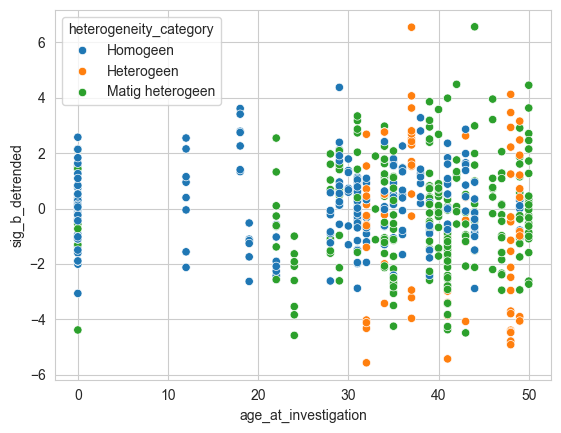

In [4]:
# df_detrended['nonlog_detrended_residuals'] = df_detrended['sig_b'] - np.exp(df_detrended['sig_b_regression'])
df_detrended['sig_b_detrended'] = df_detrended['sig_b'] - np.exp(df_detrended['log_sig_b_regression'])

#add some section characteristics to df_detrended
df_detrended = pd.merge(df_detrended, data_per_dike_project[['project_dike_id','sig_b_mean', 'sig_b_std']], on='project_dike_id', how='left')

#remove data for age_at_investigation >50
df_detrended = df_detrended[df_detrended['age_at_investigation'] <=50]

# sns.scatterplot(data=df_detrended, x='age_at_investigation', y='nonlog_detrended_residuals', hue='heterogeneity_category')
sns.scatterplot(data=df_detrended, x='age_at_investigation', y='sig_b_detrended', hue='heterogeneity_category')

<Axes: xlabel='age_at_investigation', ylabel='log_sig_b_detrended'>

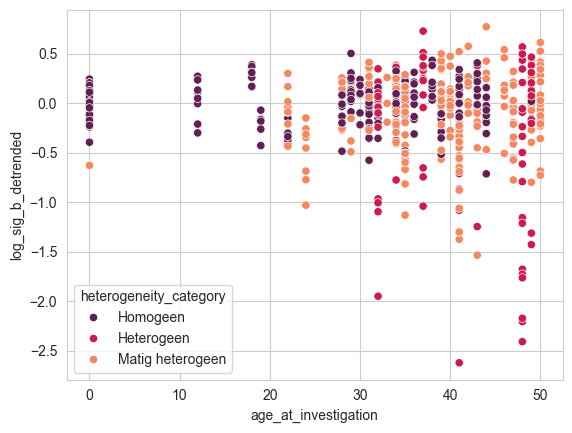

In [5]:
sns.scatterplot(data=df_detrended, x='age_at_investigation', y= 'log_sig_b_detrended', hue='heterogeneity_category', palette='rocket')

In [6]:
df_detrended = df_detrended.loc[(df_detrended["sig_b"]>0) & (~df_detrended["sig_b"].isna())]
#test for heteroscedasticity in detrended data
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
X = df_detrended[['age_at_investigation']]
X = sm.add_constant(X)  # add constant term
y = df_detrended['log_sig_b_detrended']
model = sm.OLS(y, X).fit()
residuals = model.resid
bp_test = het_breuschpagan(residuals, X)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
dict(zip(labels, bp_test)) 



{'Lagrange multiplier statistic': np.float64(16.83183494010072),
 'p-value': np.float64(4.084238103573887e-05),
 'f-value': np.float64(17.270452229148006),
 'f p-value': np.float64(3.727207834079618e-05)}

In [7]:
#test for heteroscedasticity in detrended data but only for homogeneous sections
df_detrended_sub = df_detrended[df_detrended['heterogeneity_category'] == 'Homogeen']
X = df_detrended_sub[['age_at_investigation']]
X = sm.add_constant(X)  # add constant term
y = df_detrended_sub['log_sig_b_detrended']
model = sm.OLS(y, X).fit()
residuals = model.resid
bp_test = het_breuschpagan(residuals, X)
labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
dict(zip(labels, bp_test))

{'Lagrange multiplier statistic': np.float64(3.6590562308154175),
 'p-value': np.float64(0.05576521266156728),
 'f-value': np.float64(3.6843144325326764),
 'f p-value': np.float64(0.056102464500632235)}

<Axes: xlabel='HR', ylabel='log_sig_b_detrended'>

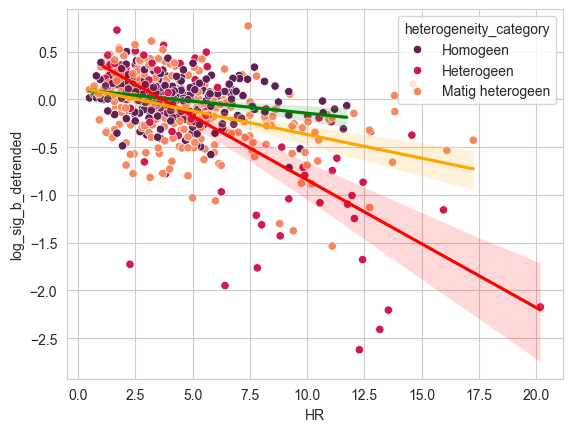

In [8]:
sns.scatterplot(data=df_detrended, x='HR', y= 'log_sig_b_detrended', hue='heterogeneity_category', palette='rocket')
sns.regplot(data=df_detrended.loc[df_detrended['heterogeneity_category'] == 'Homogeen'], x='HR', y= 'log_sig_b_detrended', scatter=False, color='green')
sns.regplot(data=df_detrended.loc[df_detrended['heterogeneity_category'] == 'Heterogeen'], x='HR', y= 'log_sig_b_detrended', scatter=False, color='red')
sns.regplot(data=df_detrended.loc[df_detrended['heterogeneity_category'] == 'Matig heterogeen'], x='HR', y= 'log_sig_b_detrended', scatter=False, color='orange')

#drop Matig heterogeen
# df_detrended = df_detrended[df_detrended['heterogeneity_category'] != 'Matig heterogeen']

## Fitting a distribution to represent the statistical uncertainty

<Axes: xlabel='age_at_investigation', ylabel='sig_b_detrended'>

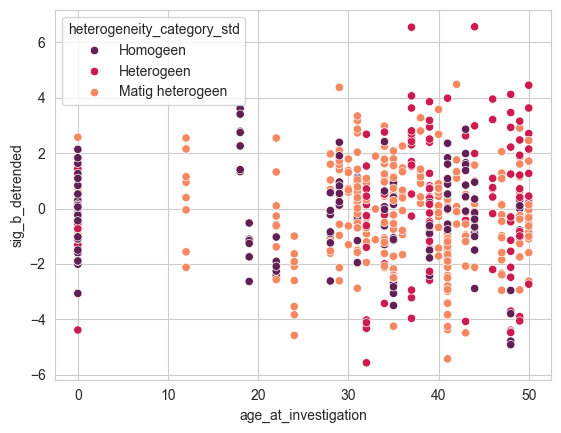

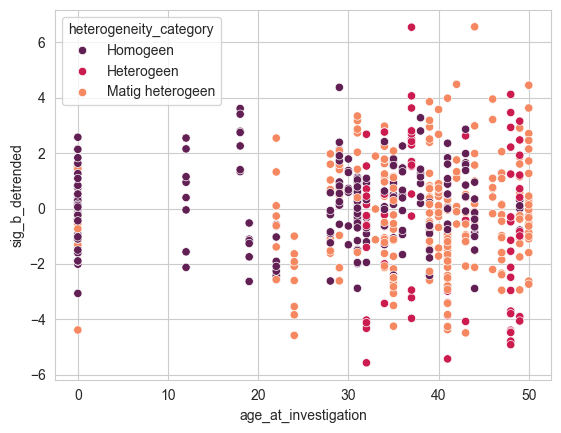

In [9]:
#In data_per_dike_project, make a new column called heterogeneity category based on sig_b_cov
def categorize_heterogeneity_std(std):
    if std < 1.0:
        return 'Homogeen'
    elif 1.0 <= std < 1.8:
        return 'Matig heterogeen'
    elif std >= 1.8:
        return 'Heterogeen'
data_per_dike_project['heterogeneity_category_std'] = data_per_dike_project['sig_b_std'].apply(categorize_heterogeneity_std)
df_detrended_adjusted = pd.merge(df_detrended, data_per_dike_project[['project_dike_id', 'heterogeneity_category_std']], on='project_dike_id', how='left')

sns.scatterplot(data=df_detrended_adjusted, x='age_at_investigation', y= 'sig_b_detrended', hue='heterogeneity_category_std', palette='rocket')
plt.figure()
sns.scatterplot(data=df_detrended_adjusted, x='age_at_investigation', y= 'sig_b_detrended', hue='heterogeneity_category', palette='rocket')

Normal fit: mu=0, std=1.3531033638892562


<Axes: xlabel='age_at_investigation', ylabel='sig_b_detrended'>

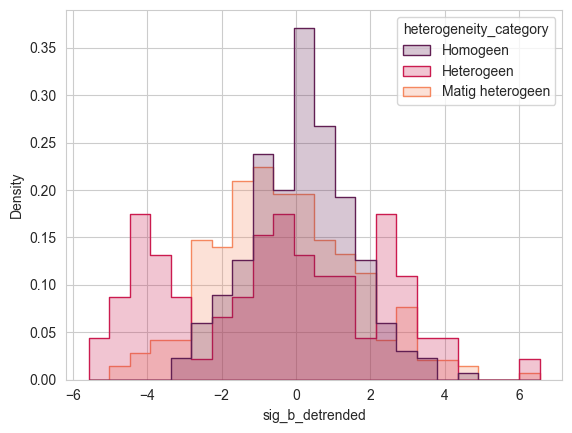

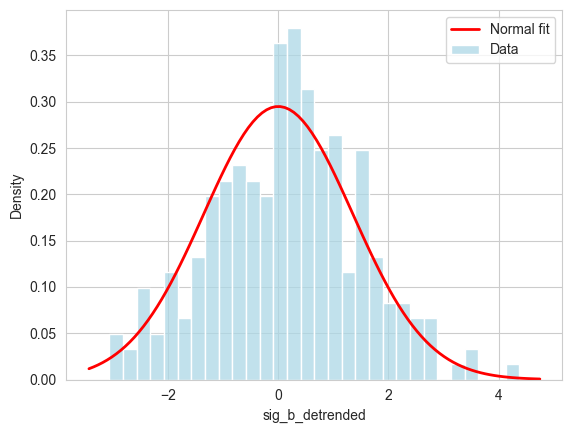

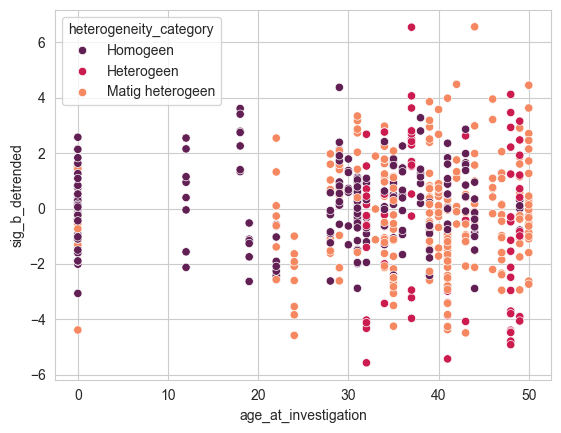

In [10]:
#FOUT: dit moet op vakniveau
plt.figure()
sns.histplot(data=df_detrended, x='sig_b_detrended', hue='heterogeneity_category', element='step', stat='density', common_norm=False, palette='rocket')

#fit a normal or lognormal distribution to the detrended residuals for Homogeen
import scipy.stats as stats
df_detrended_homogeen = df_detrended[df_detrended['heterogeneity_category'] == 'Homogeen']
# df_detrended_homogeen = df_detrended[df_detrended['sig_b_std'] <1.3]
# Fit a normal distribution. where mu = 0
mu, std = stats.norm.fit(df_detrended_homogeen['sig_b_detrended'], floc=0)
print(f'Normal fit: mu={mu}, std={std}')

#plot the histogram and the fitted distributions
plt.figure()
sns.histplot(df_detrended_homogeen['sig_b_detrended'], bins=30, kde=False, stat='density', color='lightblue', label='Data')
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p_norm = stats.norm.pdf(x, mu, std)
plt.plot(x, p_norm, 'r-', lw=2, label='Normal fit')
plt.legend()

plt.figure()
sns.scatterplot(data=df_detrended, x='age_at_investigation', y= 'sig_b_detrended', hue='heterogeneity_category', palette='rocket')


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              sig_b_cov   R-squared:                       0.347
Model:                            OLS   Adj. R-squared:                  0.339
Method:                 Least Squares   F-statistic:                     44.67
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           2.40e-09
Time:                        17:10:14   Log-Likelihood:                 55.811
No. Observations:                  86   AIC:                            -107.6
Df Residuals:                      84   BIC:                            -102.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0616      0.033      1.879      0.064      -0.004       0.127
HR_mean        0.0401      0.006      6.684      0.000       0.028       0.052
==============================================================================
Omnibus:                       21.548   Durbin-Watson:                   1.639
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               34.551
Skew:                           1.023   Prob(JB):                     3.14e-08
Kurtosis:                       5.337   Cond. No.                         13.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

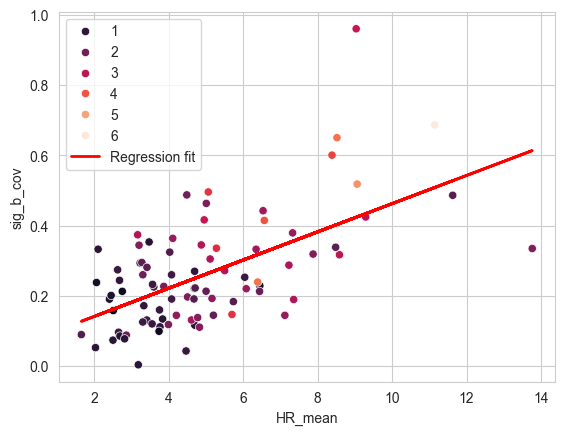

In [11]:
#based on heterogeneous dataset we make a regression model to predict the expected variation of sig_b based on HR
data_per_dike_project_nonans = data_per_dike_project.loc[~data_per_dike_project['sig_b_cov'].isna()]
# X = data_per_dike_project[['HR_mean', 'age_at_investigation']]
X = data_per_dike_project_nonans['HR_mean']
X = sm.add_constant(X)  # add constant term
y = data_per_dike_project_nonans['sig_b_cov']
model = sm.OLS(y, X).fit()
y_pred = model.predict(X)
model.summary()

plt.figure()
# plt.plot(X,y, 'o')
sns.scatterplot(data=data_per_dike_project_nonans, x='HR_mean', y= 'sig_b_cov', hue='HR_std', palette='rocket')
plt.plot(data_per_dike_project_nonans['HR_mean'], y_pred, 'r-', lw=2, label='Regression fit')
plt.legend()

model.summary()

<Axes: xlabel='HR_mean', ylabel='sig_b_std'>

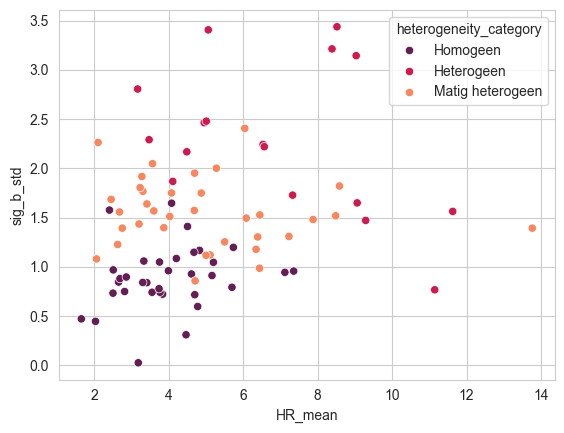

In [14]:
#cov in time
sns.scatterplot(data=data_per_dike_project, x='HR_mean', y= 'sig_b_std', hue='heterogeneity_category', palette='rocket')


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_19600\343996848.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_detrended, x='HR_category', y='sig_b_detrended', palette='rocket')
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_19600\343996848.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_detrended, x='age_category', y='sig_b_detrended', palette='rocket')


<Axes: xlabel='age_category', ylabel='sig_b_detrended'>

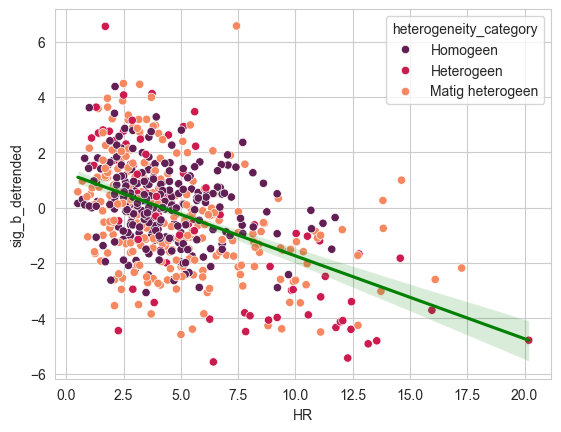

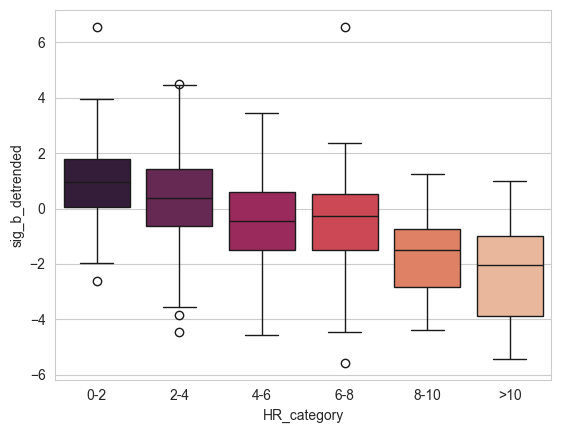

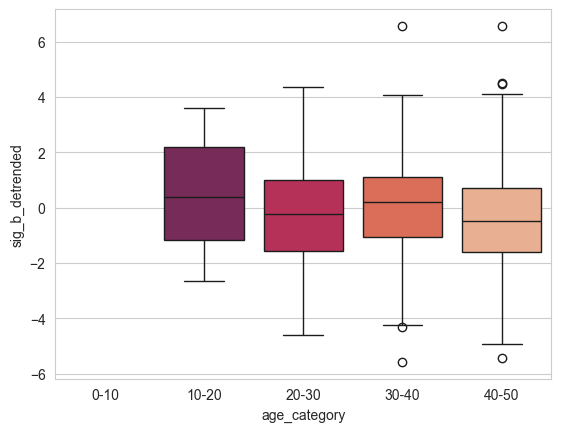

In [15]:
sns.scatterplot(data=df_detrended, x='HR', y= 'sig_b_detrended', hue='heterogeneity_category', palette='rocket')
#regplot
sns.regplot(data=df_detrended, x='HR', y= 'sig_b_detrended', scatter=False, color='green')

#boxplot of sig_b_detrended for HR between 0-2, 2-4, 4-6, 6-8, 8-10, >10
df_detrended['HR_category'] = pd.cut(df_detrended['HR'], bins=[0,2,4,6,8,10, np.inf], labels=['0-2','2-4','4-6','6-8','8-10','>10'])
plt.figure()
sns.boxplot(data=df_detrended, x='HR_category', y='sig_b_detrended', palette='rocket')

#same for age categories
df_detrended['age_category'] = pd.cut(df_detrended['age_at_investigation'], bins=[0,10,20,30,40,50], labels=['0-10','10-20','20-30','30-40','40-50'])
plt.figure()
sns.boxplot(data=df_detrended, x='age_category', y='sig_b_detrended', palette='rocket')

<Axes: xlabel='age_at_investigation', ylabel='sig_b_detrended'>

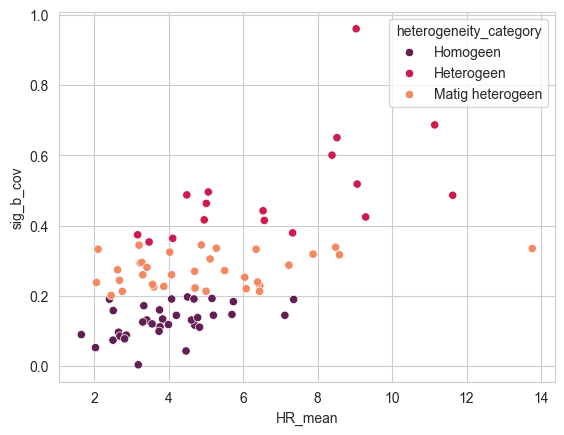

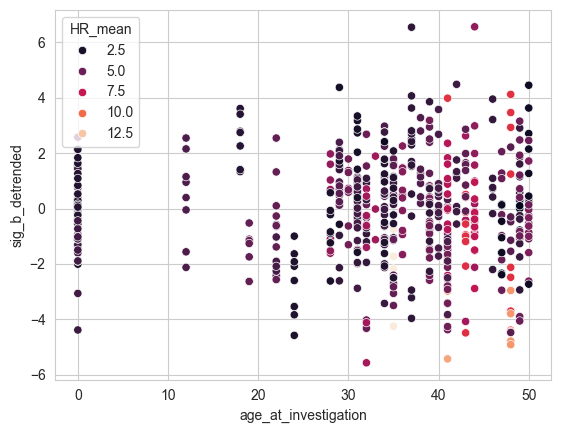

In [17]:
#is there a relation between the mean sig_b and the mean HR
plt.figure()
sns.scatterplot(data=data_per_dike_project, x='HR_mean', y='sig_b_cov', hue='heterogeneity_category', palette='rocket')

df_detrended_adjusted = pd.merge(df_detrended, data_per_dike_project[['project_dike_id', 'HR_mean']], on='project_dike_id', how='left')
plt.figure()
sns.scatterplot(data=df_detrended_adjusted, x='age_at_investigation', y= 'sig_b_detrended', hue='HR_mean', palette='rocket')

## try and separate the degradation part of the variation

Intercept: {'Coef.': 2.2395381791937847, 'Std.Err.': 0.024859834023103957, 't': 90.08661027714133, 'P>|t|': 5.568479666662864e-197, '[0.025': 2.1905841595739597, '0.975]': 2.2884921988136098}, Slope: {'Coef.': -0.01151639929838901, 'Std.Err.': 0.0007817846298140572, 't': -14.730910354592307, 'P>|t|': 4.670485050914071e-36, '[0.025': -0.013055890675154709, '0.975]': -0.00997690792162331}


C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_19600\2792809026.py:34: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y= 'sig_b_cov_degradation',  palette='rocket')
C:\Users\klerk_wj\AppData\Local\Temp\ipykernel_19600\2792809026.py:37: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=data_per_dike_project, x='sig_b_cov_degradation', y= 'sig_b_mean',  palette='rocket')


<Axes: xlabel='sig_b_cov_degradation', ylabel='sig_b_mean'>

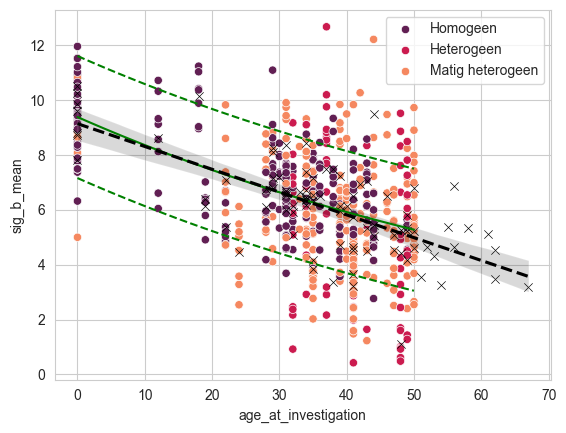

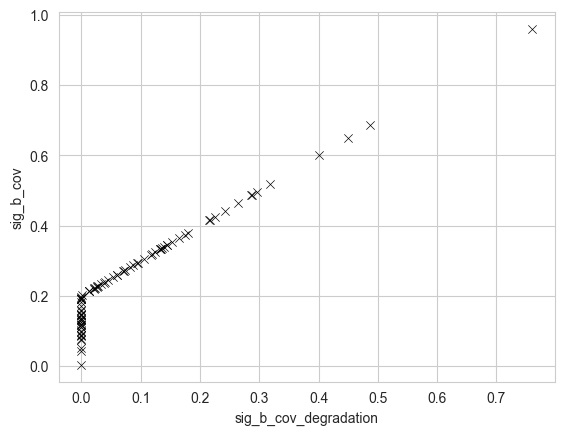

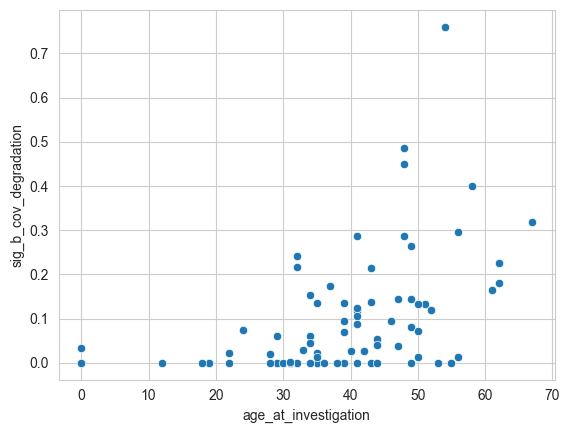

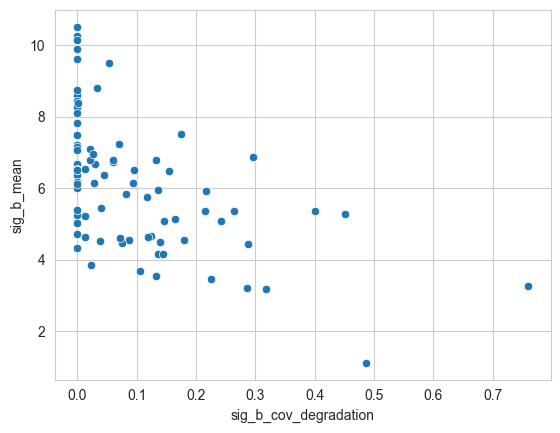

In [18]:
#plot sig_b and include the regression line from the homogeneous dataset
sns.scatterplot(data=df_detrended, x= 'age_at_investigation', y = 'sig_b', hue='heterogeneity_category', palette='rocket')

#import regression coefficients from json

import json
with open(working_dir.joinpath('heterogeneity_regression', 'log_y_True','lr_results.json')) as f:
    lr_results = json.load(f)
    intercept = lr_results['Homogeen']['summary_dict']['const']
    slope = lr_results['Homogeen']['summary_dict']['age_at_investigation']

x_grid = np.linspace(0, max(df_detrended['age_at_investigation']), 100)
prediction_y = np.exp(intercept['Coef.'] + slope['Coef.'] * x_grid)
plt.plot(x_grid, prediction_y, color='green')
#minus the standard deviation line
plt.plot(x_grid, prediction_y - 1.645*std, color='green', linestyle='dashed')
#plus the standard deviation line
plt.plot(x_grid, prediction_y + 1.645*std, color='green', linestyle='dashed')
print(f'Intercept: {intercept}, Slope: {slope}')
# sns.regplot(data=df_detrended.loc[df_detrended['heterogeneity_category'] == 'Homogeen'], x='age_at_investigation', y='sig_b', scatter=False, color='green')
#add dashed lines for regression - standard deviation and + standard deviation
#plot data for dike sections as well
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', color='black', marker='x')
sns.regplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', scatter=False, color='black', line_kws={'linestyle':'dashed'})

plt.figure()
#extra cov per dijkvak
#additional cov, subtract 0.2 take absolute value, and then
data_per_dike_project['sig_b_cov_degradation']  = data_per_dike_project['sig_b_cov'] - 0.2
data_per_dike_project['sig_b_cov_degradation'] = np.where(data_per_dike_project['sig_b_cov_degradation']  < 0.0, 0.0, data_per_dike_project['sig_b_cov_degradation'] )
sns.scatterplot(data=data_per_dike_project, x='sig_b_cov_degradation', y='sig_b_cov', color='black', marker='x')

plt.figure()
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y= 'sig_b_cov_degradation',  palette='rocket')

plt.figure()
sns.scatterplot(data=data_per_dike_project, x='sig_b_cov_degradation', y= 'sig_b_mean',  palette='rocket')




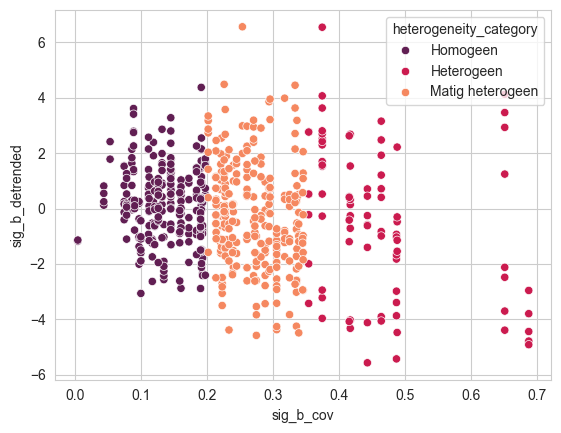

In [19]:
#get the matig heterogeen data and investigate the sig_b_cov
# df_detrended_matig = pd.merge(df_detrended_matig, data_per_dike_project[['project_dike_id', 'sig_b_cov']], on='project_dike_id', how='left')
sns.scatterplot(data=df_detrended, x='sig_b_cov', y= 'sig_b_detrended', hue = 'heterogeneity_category', palette='rocket')

#for all sig_b_cov  > 0.2 we make a model that predicts that additional variation given an increase in sig_b_cov. It should have y = variance of sig_b_detrended and x = sig_b_cov and age_at_investigation

df_detrended_sig_b_cov_high = df_detrended[df_detrended['sig_b_cov'] > 0.2]
X = df_detrended_sig_b_cov_high[['sig_b_cov', 'age_at_investigation']]
X = sm.add_constant(X)  # add constant term
y = df_detrended_sig_b_cov_high['sig_b_detrended'] ** 2
model = sm.OLS(y, X).fit()
residuals = model.resid





                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     9.600
Date:                Tue, 11 Nov 2025   Prob (F-statistic):            0.00204
Time:                        17:10:48   Log-Likelihood:                -1806.9
No. Observations:                 586   AIC:                             3618.
Df Residuals:                     584   BIC:                             3627.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.8076 

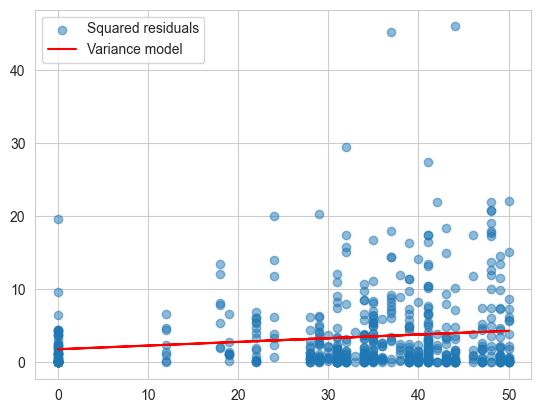

In [20]:

# Fit initial regression
X = df_detrended['age_at_investigation']
y = df_detrended['sig_b_detrended']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
residuals = model.resid

# Model variance as function of x
var_model = sm.OLS(residuals**2, sm.add_constant(X)).fit()
print(var_model.summary())

# Plot variance vs x
plt.scatter(X['age_at_investigation'], residuals**2, alpha=0.5, label="Squared residuals")
plt.plot(X['age_at_investigation'], var_model.predict(sm.add_constant(X['age_at_investigation'])), color="red", label="Variance model")
plt.legend()
plt.show()


In [21]:
df_detrended['brittleness'] = df_detrended.apply(classify_brittleness, axis=1)
df_detrended['construction_period'] = df_final.construction_year.apply(categorize_annum)

<Axes: xlabel='HR', ylabel='log_sig_b_detrended'>

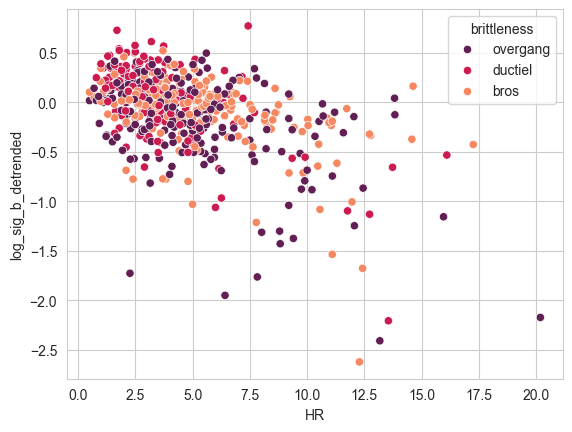

In [22]:
sns.scatterplot(data=df_detrended, x='HR', y= 'log_sig_b_detrended', hue='brittleness', palette='rocket')


<Axes: xlabel='HR', ylabel='log_sig_b_detrended'>

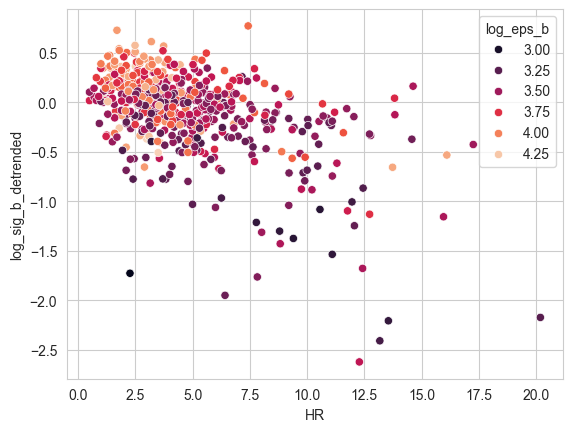

In [23]:
# sns.scatterplot(data=df_detrended, x='HR', y= 'sig_b_detrended', hue='construction_period', palette='rocket')
df_detrended['log_eps_b'] = np.log10(df_detrended['eps_b'])
sns.scatterplot(data=df_detrended, x='HR', y= 'log_sig_b_detrended', hue='log_eps_b', palette='rocket')


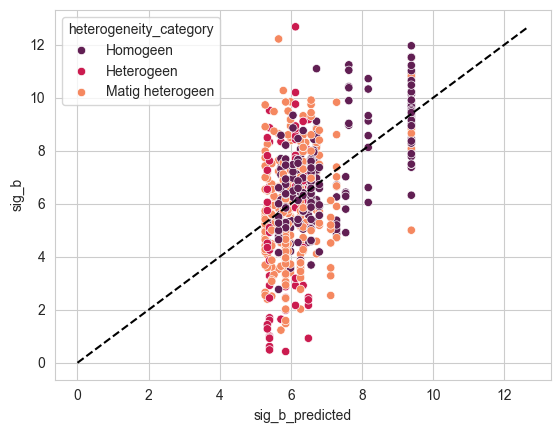

In [24]:
#add ln of sig_b
df_detrended['log_sig_b'] = np.log(df_detrended['sig_b'])
df_detrended['sig_b_detrended'] = np.exp(df_detrended['log_sig_b_detrended'])
df_detrended['sig_b_predicted'] = np.exp(df_detrended['log_sig_b_regression'])
sns.scatterplot(data=df_detrended, x= 'sig_b_predicted', y = 'sig_b', hue='heterogeneity_category', palette='rocket')
#add xy line
plt.plot([0, max(df_detrended['sig_b'])], [0, max(df_detrended['sig_b'])], color='black', linestyle='--')

<Axes: xlabel='age_at_investigation', ylabel='sig_b_detrended'>

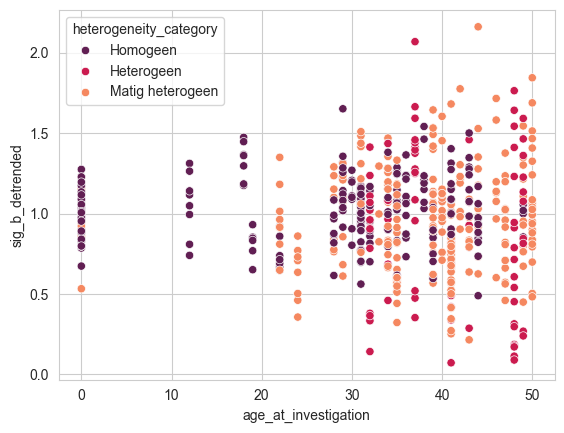

In [25]:
sns.scatterplot(data=df_detrended, x='age_at_investigation', y= 'sig_b_detrended', hue='heterogeneity_category', palette='rocket')

<Axes: xlabel='HR', ylabel='E_50'>

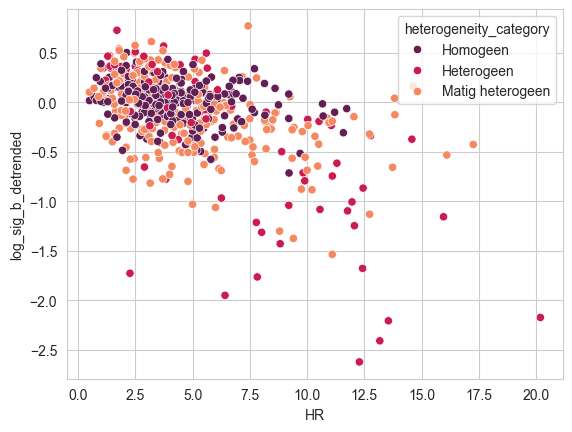

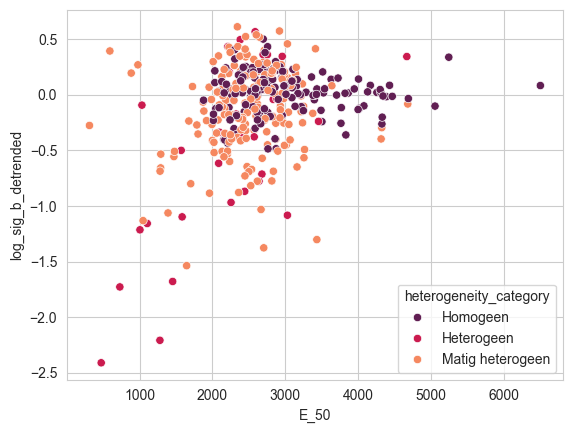

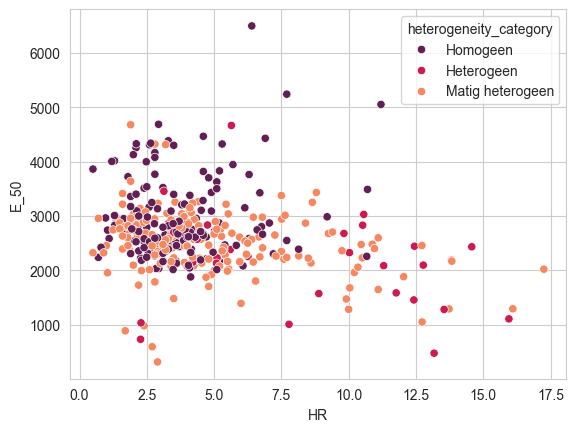

In [26]:
sns.scatterplot(data=df_detrended, x='HR', y= 'log_sig_b_detrended', hue='heterogeneity_category', palette='rocket')

plt.figure()
#scatterplot of eps_b vs sig_b_detrended
sns.scatterplot(data=df_detrended, x='E_50', y= 'log_sig_b_detrended', hue='heterogeneity_category', palette='rocket')

plt.figure()

#scatterplot of eps_b vs sig_b_detrended
sns.scatterplot(data=df_detrended, x='HR', y= 'E_50', hue='heterogeneity_category', palette='rocket')


<Axes: >

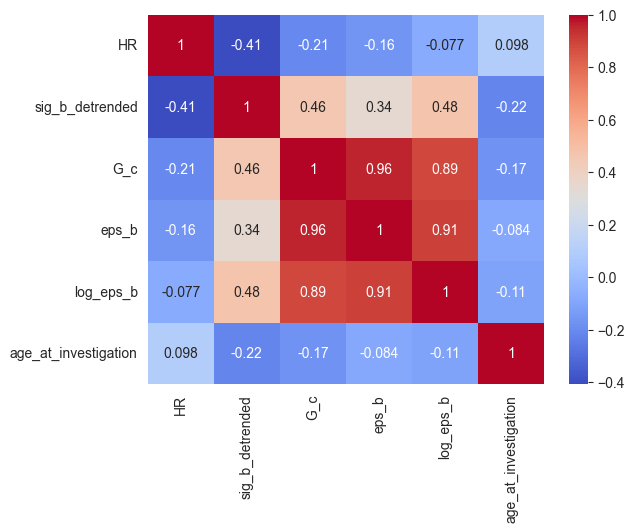

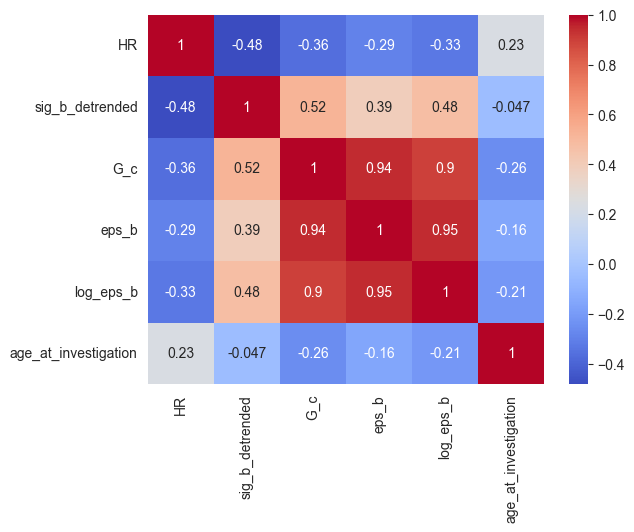

In [27]:
#check what distinguishes sections where sig_b_detrended is <-0.5 and HR <9 from others
df_detrended_sub = df_detrended[(df_detrended['log_sig_b_detrended'] <-0.5) & (df_detrended['HR'] <9)]

#make a correlation matrix of df_detrended_sub

#get key fields
key_fields = ['HR', 'sig_b_detrended', 'G_c', 'eps_b', 'log_eps_b', 'age_at_investigation']
corr = df_detrended_sub[key_fields].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.figure()

corr2 = df_detrended[key_fields].corr()
sns.heatmap(corr2, annot=True, cmap='coolwarm')

Pearson resid/stiffness: -0.0029358896030460793, 0.971364203717574
Spearman resid/stiffness: 0.02184961389865877, 0.789324177462122
Pearson resid/HR: -0.25637890489227044, 5.075225301318098e-05
Spearman resid/HR: -0.25656486839520476, 5.009633472746841e-05


Text(0.5, 1.0, 'Spearman for Homogeen sections')

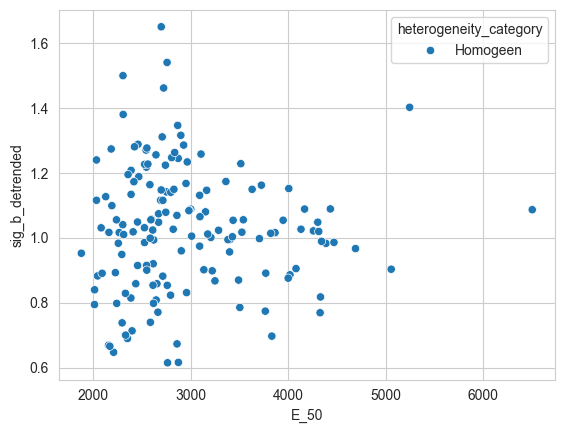

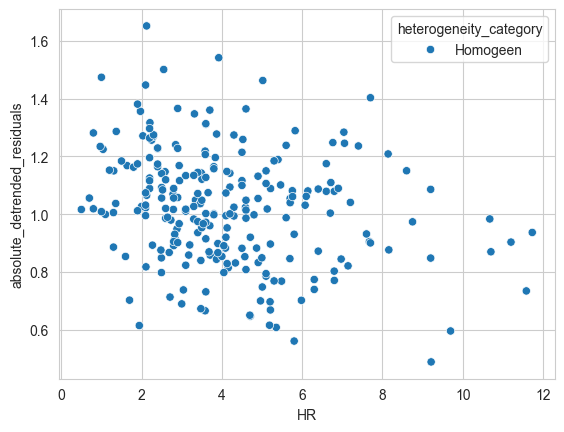

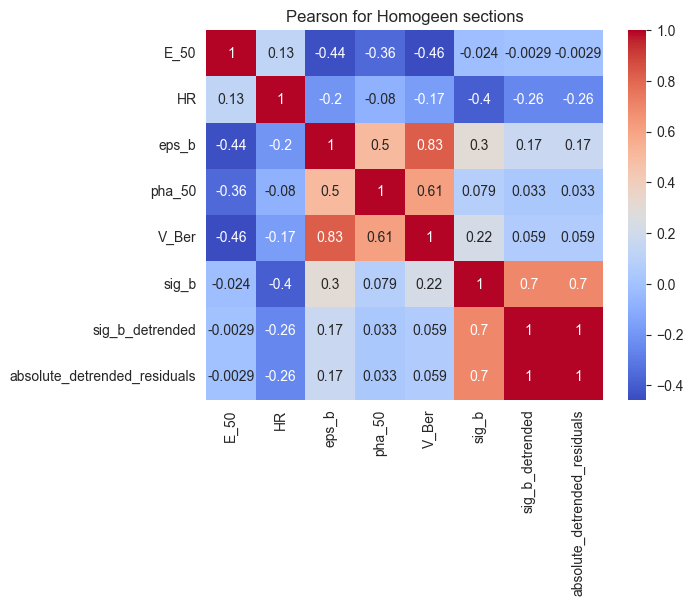

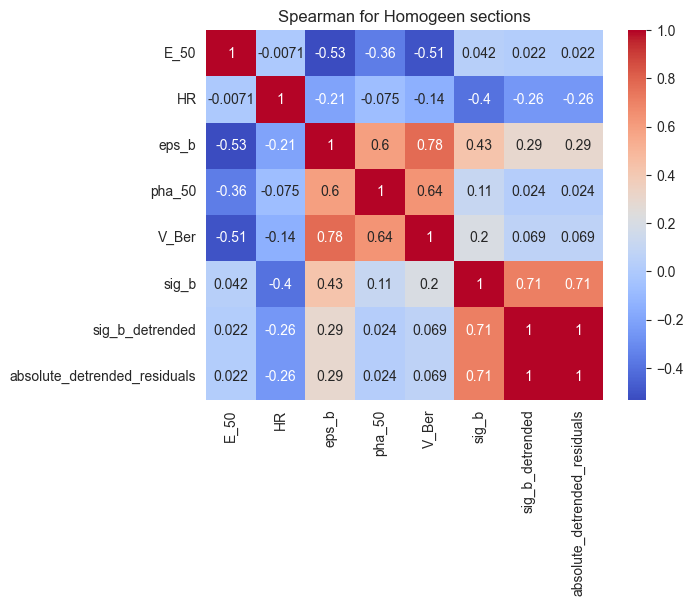

In [28]:
#for the detrended residuals, take the absolute value, and check the correlation with E_50
absolute_detrended_residuals = df_detrended['sig_b_detrended'].abs()
df_detrended['absolute_detrended_residuals'] = absolute_detrended_residuals
subset= 'Homogeen'
df_detrended_analysis = df_detrended.loc[df_detrended.heterogeneity_category == subset]
sns.scatterplot(data=df_detrended_analysis, x='E_50', y= absolute_detrended_residuals, hue='heterogeneity_category')
#compute the correlation coefficient
from scipy.stats import pearsonr
#find non-nan indices
non_nan_indices = df_detrended_analysis['absolute_detrended_residuals'].notna() & df_detrended_analysis['E_50'].notna()
corr_coef, p_value = pearsonr(df_detrended_analysis['E_50'][non_nan_indices], df_detrended_analysis['absolute_detrended_residuals'][non_nan_indices])
print(f"Pearson resid/stiffness: {corr_coef}, {p_value}")

#spearman
from scipy.stats import spearmanr
corr_coef_s, p_value_s = spearmanr(df_detrended_analysis['E_50'][non_nan_indices], df_detrended_analysis['absolute_detrended_residuals'][non_nan_indices])
print(f"Spearman resid/stiffness: {corr_coef_s}, {p_value_s}")

#same for HR
plt.figure()
sns.scatterplot(data=df_detrended_analysis, x='HR', y= 'absolute_detrended_residuals', hue='heterogeneity_category')
#compute the correlation coefficient
non_nan_indices_hr = df_detrended_analysis['absolute_detrended_residuals'].notna() & df_detrended_analysis['HR'].notna()
corr_coef_hr, p_value_hr = pearsonr(df_detrended_analysis['HR'][non_nan_indices_hr], df_detrended_analysis['absolute_detrended_residuals'][non_nan_indices_hr])
print(f"Pearson resid/HR: {corr_coef_hr}, {p_value_hr}")

corr_coef_s_hr, p_value_s_hr = spearmanr(df_detrended_analysis['HR'][non_nan_indices_hr], df_detrended_analysis['absolute_detrended_residuals'][non_nan_indices_hr])
print(f"Spearman resid/HR: {corr_coef_s_hr}, {p_value_s_hr}")

#make correlation matrix for E_50, HR, eps_b, pha_50, V_Ber, sig_b_detrended, absolute_detrended_residuals
key_fields_2 = ['E_50', 'HR', 'eps_b', 'pha_50', 'V_Ber', 'sig_b', 'sig_b_detrended', 'absolute_detrended_residuals']
corr3 = df_detrended_analysis[key_fields_2].corr()
plt.figure()
sns.heatmap(corr3, annot=True, cmap='coolwarm', )
plt.title(f'Pearson for {subset} sections')
plt.figure()
#spearman
corr4 = df_detrended_analysis[key_fields_2].corr(method='spearman')
sns.heatmap(corr4, annot=True, cmap='coolwarm', )
plt.title(f'Spearman for {subset} sections')

## Analysis for statistical uncertainty

<Axes: >

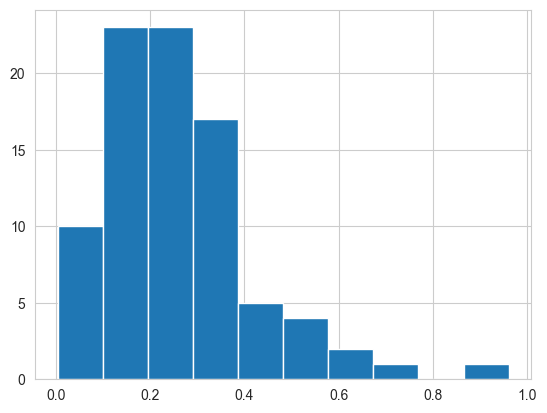

In [29]:
data_per_dike_project.sig_b_cov.hist()
